## Homework 7: Clustering & PCA with High-Dimensional Data
Objective:
To determine if K-Means or DBSCAN can accurately breast cancer patients into meaningful clusters and to evaluate the impact of PCA on high-dimensional clustering.
### Part 1: Initial Clustering 
Load the dataset (from sklearn.datasets import load_breast_cancer

data = load_breast_cancer )

drop the "target" column (Diagnosis). You should only have the 30 numerical features.
Standardization: Apply StandardScaler. This is mandatory as features have vastly different scales. Then Cluster the data using k-means and DBSCAN algorithm.
 - K-Means: Use the Elbow Method to suggest an optimal K, But if not 2, use K=2
 - DBSCAN: Attempt to find an appropriate eps and min_samples.
 - Metrics: Calculate the Silhouette Score for both
 
### Part 2: Dimensionality Reduction (PCA)
    - Perform PCA: Run PCA on your scaled 30-feature data.
    - Variance Analysis: Plot the Cumulative Explained Variance ratio.
    - Identify the minimum number of Principal Components (PCs) needed to capture ~85% of the variance.
    - Interpretation: Plot the heatmap of loading. Also identify which 3 original features contribute the most to Principal Component 1?
    
### Part 3: Clustering Using Principal Components
    - Reduce your dataset to the number of PCs identified in Part 2.
    - Run K-Means (K=2) on the PCA-transformed data.
    - Run DBSCAN on the PCA-transformed data.
    - Metric Comparison: Compare the Silhouette Score of the PCA-based clusters against the 30-feature clusters from Part 1.
    
   
### Part 4: Visual Validation
    - Scatter Plot: Create a 2D plot using PC1 and PC2, Color the points using your K-Means labels (If your Kmeans .
    - Create a second version of the plot colored by the original labels (target).
    - How closely did the unsupervised K-Means clusters match the actual medical diagnosis? 

### Part 1: Initial Clustering
Load the dataset (from sklearn.datasets import load_breast_cancer

data = load_breast_cancer )

drop the "target" column (Diagnosis). You should only have the 30 numerical features. Standardization: Apply StandardScaler. This is mandatory as features have vastly different scales. Then Cluster the data using k-means and DBSCAN algorithm.

K-Means: Use the Elbow Method to suggest an optimal K, But if not 2, use K=2
DBSCAN: Attempt to find an appropriate eps and min_samples.
Metrics: Calculate the Silhouette Score for both

In [27]:
import os
os.environ["OMP_NUM_THREADS"] = "1" # Also tested with "2"
os.environ["MKL_NUM_THREADS"] = "1"
import numpy as np
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

In [28]:
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = cancer.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

kmeans_30 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_km_30 = kmeans_30.fit_predict(X_scaled)

dbscan_30 = DBSCAN(eps=5, min_samples=5)
labels_db_30 = dbscan_30.fit_predict(X_scaled)

print(f"K-Means (30 features) Silhouette: {silhouette_score(X_scaled, labels_km_30):.3f}")
if len(set(labels_db_30)) > 1:
    print(f"DBSCAN (30 features) Silhouette: {silhouette_score(X_scaled, labels_db_30):.3f}")

C:\Users\hwang\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\hwang\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\hwang\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\hwang\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

K-Means (30 features) Silhouette: 0.343
DBSCAN (30 features) Silhouette: 0.481


C:\Users\hwang\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


Part 2: Dimensionality Reduction (PCA)
- Perform PCA: Run PCA on your scaled 30-feature data.
- Variance Analysis: Plot the Cumulative Explained Variance ratio.
- Identify the minimum number of Principal Components (PCs) needed to capture ~85% of the variance.
- Interpretation: Plot the heatmap of loading. Also identify which 3 original features contribute the most to Principal Component 1?

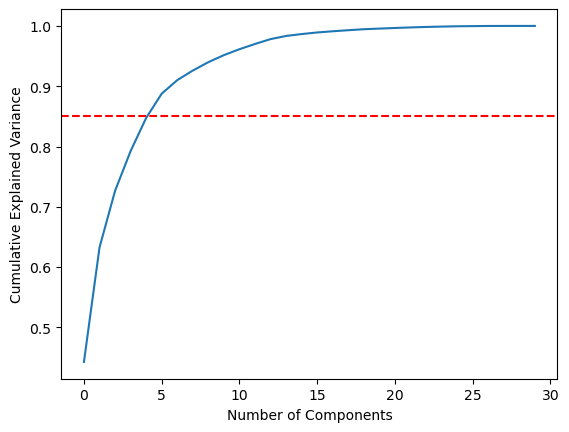

Number of PCs to capture 85% variance: 6


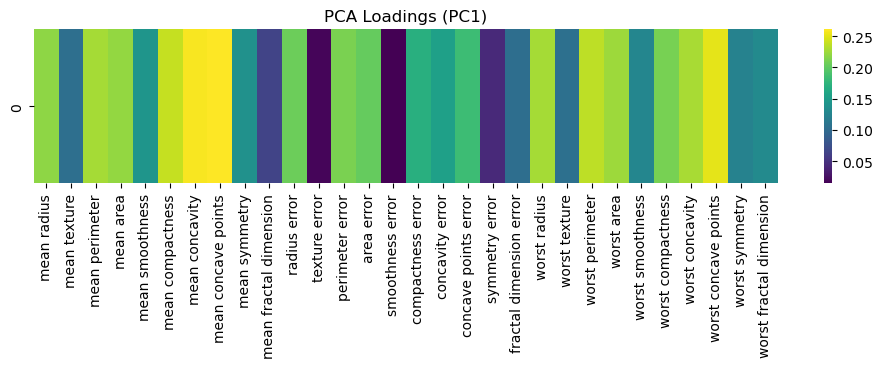

Top 3 features contributing to PC1:
mean concave points     0.260854
mean concavity          0.258400
worst concave points    0.250886
Name: 0, dtype: float64


In [29]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_scaled)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.85, color='r', linestyle='--')
plt.show()

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_85 = np.where(cumulative_variance >= 0.85)[0][0] + 1
print(f"Number of PCs to capture 85% variance: {n_components_85}")

components = pd.DataFrame(pca.components_, columns=cancer.feature_names)
plt.figure(figsize=(12, 2))
sns.heatmap(components.iloc[:1, :], annot=False, cmap='viridis')
plt.title("PCA Loadings (PC1)")
plt.show()

top_3_features = components.iloc[0].abs().sort_values(ascending=False).head(3)
print("Top 3 features contributing to PC1:")
print(top_3_features)

In [30]:
pca_final = PCA(n_components=n_components_85)
X_pca = pca_final.fit_transform(X_scaled)

kmeans_pca = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_km_pca = kmeans_pca.fit_predict(X_pca)

dbscan_pca = DBSCAN(eps=3, min_samples=5)
labels_db_pca = dbscan_pca.fit_predict(X_pca)

print(f"K-Means (PCA) Silhouette: {silhouette_score(X_pca, labels_km_pca):.3f}")

K-Means (PCA) Silhouette: 0.378


C:\Users\hwang\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


### Part 3: Clustering Using Principal Components
- Reduce your dataset to the number of PCs identified in Part 2.
- Run K-Means (K=2) on the PCA-transformed data.
- Run DBSCAN on the PCA-transformed data.
- Metric Comparison: Compare the Silhouette Score of the PCA-based clusters against the 30-feature clusters from Part 1.

In [31]:
pca_final = PCA(n_components=n_components_85)
X_pca = pca_final.fit_transform(X_scaled)

kmeans_pca = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_km_pca = kmeans_pca.fit_predict(X_pca)

dbscan_pca = DBSCAN(eps=3, min_samples=5)
labels_db_pca = dbscan_pca.fit_predict(X_pca)

print(f"K-Means (PCA) Silhouette: {silhouette_score(X_pca, labels_km_pca):.3f}")

K-Means (PCA) Silhouette: 0.378


C:\Users\hwang\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


### Part 4: Visual Validation
- Scatter Plot: Create a 2D plot using PC1 and PC2, Color the points using your K-Means labels (If your Kmeans .
- Create a second version of the plot colored by the original labels (target).
- How closely did the unsupervised K-Means clusters match the actual medical diagnosis?

While some overlap occurs at the boundaries of the clusters, it seems the unsupervised K-Means clusters  match the actual medical diagnosis with high accuracy since the malignant and benign classes are well-separated.

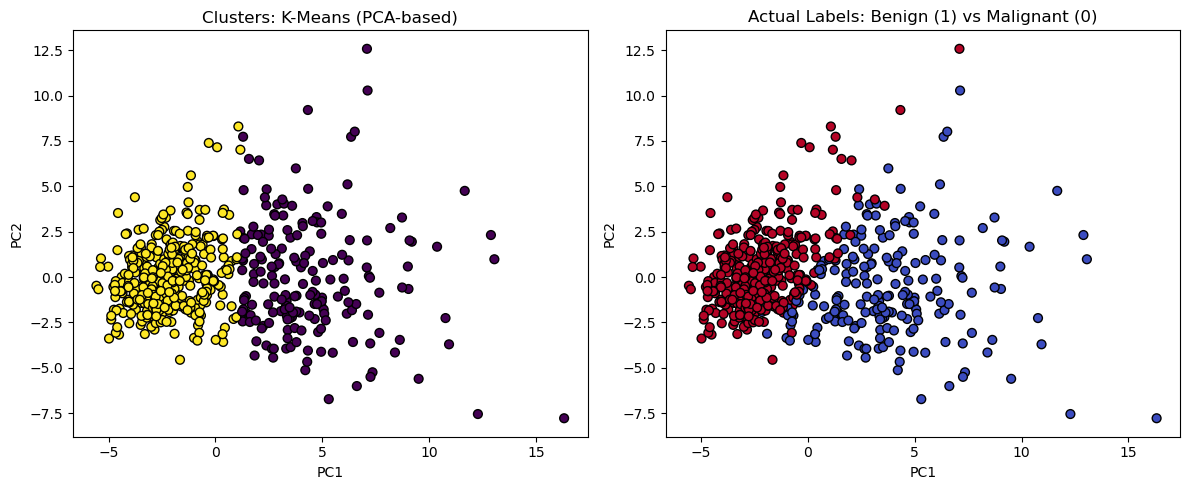

In [32]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_km_pca, cmap='viridis', edgecolor='k', s=40)
plt.title("Clusters: K-Means (PCA-based)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=40)
plt.title("Actual Labels: Benign (1) vs Malignant (0)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.show()